In [2]:
from IPython.display import display, Math, Markdown, display_latex
import typing

import sympy as sp
from sympy.printing.latex import LatexPrinter

## Setup

In [3]:
# Main parameters
dx = sp.Symbol('dx', real=True, positive=True)
dt = sp.Symbol('dt', real=True, positive=True)

a = sp.Symbol('a', real=True, positive=True)
cfl = sp.Symbol('cfl', real=True, positive=True)
sigma = sp.Symbol('sigma', latex=r'\sigma', real=True)

# dx and dt latex symbols (passed in sp.Symbol()) seem to be hard-coded to use 
# symbol names, this is a codegen-friendly workaround
symbol_names = {dx: r"\Delta x", dt: r"\Delta t", cfl: r"\nu"}
LatexPrinter.set_global_settings(symbol_names=symbol_names)

Since terms mainly featured throughout (essentially) utilize products of $\Delta x$ and $\nu$ and can reach $\nu^4 \propto 1 / \Delta x^{4}$ in powers, it is necessary to pick right maximum order to leave high enough Big-$\mathcal{O}$ terms across all computations. Most symbols in operations are threated as constants, therefore they might get wholly absorbed by $\mathcal{O}(\Delta x^{\alpha})$ terms -- that is without utilizing relanshionships between variables (such as $\Delta t \propto \Delta x$) in expansions and subsequently reducing total order when divided by any powers of $\Delta x$.

*Note: this could be probably be more elegantly (but less generally) solved if one wishes to write `sympy` constraints.*

In [4]:
# Derivatives
x = sp.Symbol('x', real=True)
u = sp.Function('u')
order = 9  # Expansion order = O(dx^9) -- the highest term kept is dx^9
derivs = tuple(sp.Derivative(u(x), (x, i)) for i in range(0, order))

In [5]:
# Stencil
u_im2 = sp.Symbol('u_im2')
u_im1 = sp.Symbol('u_im1')
u_i = sp.Symbol('u_i')
u_ip1 = sp.Symbol('u_ip1')
u_ip2 = sp.Symbol('u_ip2')
stencil = (u_im2, u_im1, u_i, u_ip1, u_ip2)

# This is just appears to be a better practice with sympy for consistency
symbol_names |= {
    stecil_point: "u^n_" + subscript for stecil_point, subscript in
    zip(stencil, ['{i - 2}', '{i - 1}', 'i', '{i + 1}', '{i + 2}'], strict=True)
}
LatexPrinter.set_global_settings(symbol_names=symbol_names)

stencil_taylors: typing.Mapping[sp.Basic | complex, sp.Expr] = {
    stecil_point: u(x + offset * dx).series(dx, 0, order).doit()
    for offset, stecil_point in enumerate(stencil, -2)
}

In [6]:
''' This cell is for small pretty printing utilities.

See

https://docs.sympy.org/latest/modules/printing.html#example-of-custom-printer

for examples.
'''

class BaseOrderedPrinter(LatexPrinter):
    '''
    Reusable Term Ordering Logic. Intercepts sympy.Add to sort terms based on 
    subclass priority rules.
    '''

    def _get_term_priority(self, term) -> tuple[int, int]:
        return (0, 0)

    def _print_Add(self, expr: sp.Expr, order=None):
        def priority_key(term):
            # Force Big-O terms to end
            if term.is_Order:
                return (99, 0)
            return self._get_term_priority(term)

        # Sort terms safely
        sorted_terms = sorted(expr.args, key=priority_key)
        ordered_expr = sp.Add(*sorted_terms, evaluate=False)

        # Print with sorting disabled so our order is respected
        old_order = self._settings.get('order')
        self._settings['order'] = 'none'
        result = super()._print_Add(ordered_expr, order='none')
        self._settings['order'] = old_order

        return result


class PrettyDerivativePrinter(LatexPrinter):
    ''' Only concerns itself with formatting u(x) and its derivatives. '''

    def _print_Function(self, expr: sp.Function, exp: sp.Expr | None = None):
        if getattr(expr.func, '__name__', '') == 'u':
            return f"u^{{{exp}}}" if exp is not None else "u"
        return super()._print_Function(expr, exp)

    def _print_Derivative(self, expr: sp.Derivative):
        func = expr.args[0]
        if getattr(getattr(func, 'func', None), '__name__', '') == 'u':
            n = len(expr.variables)
            var = expr.variables[0].name if expr.variables else 'x'
            sub = var * n

            if n == 0:
                return "u"
            elif n <= 3:
                return f"u_{{{sub}}}"
            else:
                roman = {4: 'IV', 5: 'V', 6: 'VI', 7: 'VII', 8: 'VIII'}
                return f"u^{{({roman.get(n, str(n))})}}_{{{sub}}}"

        return super()._print_Derivative(expr)


class StencilPrinter(BaseOrderedPrinter):
    ''' Sorts spatial stencil symbols. '''

    def __init__(self, settings=None):
        super().__init__(settings)
        self.stencil_syms = [
            sp.Symbol('u_im2'), sp.Symbol('u_im1'), sp.Symbol('u_i'),
            sp.Symbol('u_ip1'), sp.Symbol('u_ip2')
        ]

    def _get_term_priority(self, term):
        for i, sym in enumerate(self.stencil_syms):
            if term.has(sym):
                return (0, i)
        # Extra terms go at the end
        return (1, 0)


class SeriesPrinter(BaseOrderedPrinter, PrettyDerivativePrinter):
    ''' Sorts Taylor series by derivative degree and formats nicely. '''

    def _get_term_priority(self, term: sp.Expr):
        # Look for Derivative objects
        derivs = term.atoms(sp.Derivative)
        u_derivs = [deriv for deriv in derivs if getattr(
            getattr(deriv.args[0], 'func', None), '__name__', '') == 'u']
        if u_derivs:
            return (0, len(u_derivs[0].variables))

        # Look for base function u(x)
        funcs = term.atoms(sp.Function)
        u_funcs = [f for f in funcs if getattr(f.func, '__name__', '') == 'u']
        if u_funcs:
            return (0, 0)

        # Extra terms (constants, plain variables) go at the end
        return (1, 0)


def latex_stencil(expr: sp.Expr, **settings) -> str:
    return StencilPrinter(settings).doprint(expr)


def latex_series(expr: sp.Expr, **settings) -> str:
    return SeriesPrinter(settings).doprint(expr)

In [7]:
''' Sanity check '''
display(Markdown("Taylor expansions:"))
for stencil_point, expansion in stencil_taylors.items():
    if stencil_point != u_i: # Skip center point
        display(Math(fr"{sp.latex(stencil_point)} = {latex_series(expansion)} + \ldots"))

Taylor expansions:

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Method

In [8]:
u_next = \
    sigma * u_i + (1 - sigma) * (u_ip1 + u_im1) / 2 \
    + -a * dt * (u_ip1 - u_im1) / (2 * dx) \
    + (a * dt)**2 / 2 * (u_ip1 - 2 * u_i + u_im1) / dx**2

u_taylor: sp.Expr = u(x - a * dt).series(dt, 0, order)

In [9]:
omega = (4 * cfl**2 + 1) * (4 - cfl**2) / 5
omega = cfl**2 * (cfl**2 - 4)

u_rusanov_next = \
    u_i \
    - cfl / 12 * (-u_ip2 + 8*u_ip1 - 8*u_im1 + u_im2) \
    + cfl**2 / 8 * (u_ip2 - 2*u_i + u_im2) \
    - cfl**3 / 12 * (u_ip2 - 2*u_ip1 + 2*u_im1 - u_im2) \
    - omega / 24 * (u_ip2 - 4*u_ip1 + 6*u_i - 4*u_im1 + u_im2)

In [10]:
# from IPython import display_latex
# display_markdown
display(Math((latex_stencil(u_rusanov_next.simplify()))))

<IPython.core.display.Math object>

In [11]:
omega = sp.Symbol('omega') # Free parameter for stability

# --- Central Difference Operators ---

# mu * delta (First derivative approximation)
mu_delta = (u_ip1 - u_im1) / 2

# delta^2 (Second derivative approximation)
delta2 = u_ip1 - 2 * u_i + u_im1

# mu * delta^3 (Third derivative approximation)
mu_delta3 = (u_ip2 - 2 * u_ip1 + 2 * u_im1 - u_im2) / 2

# delta^4 (Fourth derivative approximation)
delta4 = u_ip2 - 4 * u_ip1 + 6 * u_i - 4 * u_im1 + u_im2

# --- Rusanov 3rd Order Difference Scheme ---
# Matches Equation (9) of the paper
u_rusanov_next = (
    u_i 
    + cfl * mu_delta 
    + (cfl**2 / 2) * delta2 
    + (cfl**3 - cfl) / 6 * mu_delta3 
    - (omega / 24) * delta4
)


In [12]:
u_lw_next = (
    u_i 
    - (cfl / 2) * (u_ip1 - u_im1)
    + (cfl**2 / 2) * (u_ip1 - 2 * u_i + u_im1)
)

u_lw_next_taylor = sp.expand(u_lw_next.subs(stencil_taylors))
error: sp.Expr = sp.expand(u_lw_next_taylor - u_taylor)
display(Math(latex_series(
    error.simplify().subs(a*dt, cfl*dx).simplify())
))

<IPython.core.display.Math object>

In [13]:
u_rusanov_next.subs(stencil_taylors).simplify().collect(derivs)

(1 + O(dx**9))*u(x) + (cfl*dx + O(dx**9))*Derivative(u(x), x) + (cfl**2*dx**2/2 + O(dx**9))*Derivative(u(x), (x, 2)) + (cfl**3*dx**3/6 + O(dx**9))*Derivative(u(x), (x, 3)) + (-cfl*dx**5/30 + cfl**3*dx**5/24 + O(dx**9))*Derivative(u(x), (x, 5)) + (-cfl*dx**7/252 + cfl**3*dx**7/240 + O(dx**9))*Derivative(u(x), (x, 7)) + (-dx**4*omega/24 + cfl**2*dx**4/24 + O(dx**9))*Derivative(u(x), (x, 4)) + (-dx**6*omega/144 + cfl**2*dx**6/720 + O(dx**9))*Derivative(u(x), (x, 6)) + (-dx**8*omega/1920 + cfl**2*dx**8/40320 + O(dx**9))*Derivative(u(x), (x, 8))

In [14]:
def to_stencil_form(expr: sp.Expr) -> sp.Expr:
    """ Helper function """
    return sp.collect(sp.expand(expr), stencil)

In [15]:
# u_rusanov_next_taylor = sp.expand(u_rusanov_next.subs(stencil_taylors))
# error: sp.Expr = sp.expand(u_rusanov_next_taylor - u_taylor)
# display(Math(latex_series(
#     error.simplify().subs(a*dt, cfl*dx).simplify())
# ))

u_rusanov_next = to_stencil_form(u_rusanov_next.subs(a*dt, cfl*dx)).simplify()
display(Math(latex_stencil(u_rusanov_next)))
with open('rusanov-scheme.tex', mode='w') as file:
    file.write(latex_stencil(u_rusanov_next))


<IPython.core.display.Math object>

In [16]:
# display(Markdown(""))
display(Math(
    f"u_i^{{n+1}} = {latex_stencil(sp.simplify(to_stencil_form(u_next)))}"
))
display(Math(
    f"u_i^{{n+1}} = {latex_series(sp.simplify(sp.collect(sp.expand(u_next.subs(stencil_taylors)), derivs)))}"
))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [17]:
u_next_taylor = sp.expand(u_next.subs(stencil_taylors))
error = sp.expand(u_next_taylor - u_taylor)

In [155]:
display(Math(latex_series(sp.collect(u_next_taylor.removeO(), derivs), symbol_names=symbol_names | {derivs[2]: "u_i^n"})))
with open('scheme-taylor.tex', mode='w') as file:
    file.write(latex_series(sp.collect(u_next_taylor.removeO(), derivs)))

<IPython.core.display.Math object>

In [18]:
def get_coeff(expr: sp.Expr, deriv: sp.Derivative) -> sp.Basic:
    return sp.together(sp.simplify(sp.expand(expr.doit()).coeff(deriv)))

error_coeffs = tuple(get_coeff(error, deriv) for deriv in derivs)

In [19]:
table = r"""
\begin{array} {r r r} \\
& \text{Coefficient} & \text{Error coefficient} \\
\hline \\
"""

# # Decorative purpose only
# pretty_derivs_symbol_names = {
#     deriv: fr"\dfrac{{\partial^{k} u}}{{\partial x^{k}}}"
#     for k, deriv in enumerate(derivs)
# } | {u: "u", u_x: r"\dfrac{\partial u}{\partial x}"}

# for deriv, error_coeff in zip(derivs, error_coeffs):
#     table += fr"{sp.latex(deriv, symbol_names=pretty_derivs_symbol_names)} : &\quad \
#                     {sp.latex(get_coeff(u_next_taylor, deriv), fold_short_frac=True)} &\quad \
#                     {sp.latex(error_coeff, fold_short_frac=True)} \\[1em]"

table += r"\end{array}"
display(Math(table))

<IPython.core.display.Math object>

The goal here is to strip away the common factors (like $\Delta t$, $\Delta x$, and factorial denominators from the Taylor series) to isolate the "raw" constants of the error.
*   **`* sp.factorial(k)`**: Cancels out the $1/k!$ term from the Taylor expansion.
*   **`* 6 / (a**3 * dt**3 * dx**k)`**: The leading order of the error for this specific scheme is expected to be $O(a^3 \Delta t^3)$. Dividing by this normalizes the error terms, essentially asking: *"What is the coefficient of the $k$-th derivative relative to the leading error term?"*

In [20]:
error_vector = sp.Matrix(error_coeffs[:5])
# IMPORTANT adjustment that determines the order (4th) and value of error
error_vector[4] -= ((sigma - 1) * dx**4) / 24

display(Math(fr"{sp.latex(sp.simplify(error_vector.T))}^T"))

<IPython.core.display.Math object>

This creates a $5 \times 5$ matrix representing the "structure" of the 5-point stencil ($u_{i-2}$ to $u_{i+2}$). 
*   Each row corresponds to a derivative order $k$ ($0, 1, 2, 3, 4$).
*   Each column corresponds to a stencil offset ($-2, -1, 0, 1, 2$).
*   Because we already accounted for $1/k!$ and $\Delta x^k$ in the normalization step, the Taylor coefficient for offset $j$ and order $k$ is simply $j^k$. (The `0**k if k > 0 else 1` handles the $0^0 = 1$ edge case for the $u_i$ term).

In [21]:
taylor_matrix = sp.Matrix([
    [(j * dx)**k / sp.factorial(k) for j in (-2, -1, 0, 1, 2)]
    for k in range(5)
])

# more readable format
normalization = sp.diag(*[sp.factorial(k) / dx**k for k in range(5)])

system_tex = \
    fr"{sp.latex(sp.simplify(normalization * taylor_matrix))} x = \
       {sp.latex(sp.simplify(normalization * error_vector))}"
display(Math(system_tex))

with open('taylor-coefficients-system.tex', mode='w') as file:
    file.write(system_tex)

correction_coeffs: sp.Matrix = taylor_matrix.solve(error_vector)

# pretty printing factoring out of denominator
gcd = 24 * dx**4
display(Math(
    fr"x = {sp.latex(1 / gcd)} \cdot {sp.latex(sp.simplify(correction_coeffs * gcd))}"
))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [22]:
correction_term: sp.Expr = -correction_coeffs.dot(stencil)
u_corrected = u_next + correction_term
u_corrected_taylor = sp.expand(u_corrected.subs(stencil_taylors))
error_corrected = sp.expand(u_corrected_taylor - u_taylor)

In [23]:
for deriv in derivs:
    coeff = sp.simplify(get_coeff(error_corrected, deriv))
    if coeff != 0:
        display(Markdown("Coefficient of highest-order error term ${}$:"
                         .format(PrettyDerivativePrinter().doprint(deriv))))
        display(Math(f"{sp.latex(coeff)}"))
        with open('principal-error-term.tex', mode='w') as file:
            file.write(sp.latex(coeff * deriv))
        break

Coefficient of highest-order error term $u^{(IV)}_{xxxx}$:

<IPython.core.display.Math object>

In [24]:
u_corrected_cfl: sp.Expr = sp.simplify(u_corrected.subs(a*dt, cfl*dx))

# Sanity checks
assert u_corrected_cfl.coeff(a) == 0 and u_corrected_cfl.coeff(dt) == 0, \
    "Unexpected form after rewrite"

stencil_points_coeffs: tuple[sp.Expr, ...] = tuple(
    sp.simplify(sp.expand(u_corrected_cfl).coeff(stencil_point))
    for stencil_point in stencil)  # type: ignore

assert sp.Add(*stencil_points_coeffs) == 1, "Coefficients don't sum to 1"

In [25]:
display(Markdown("Complete numerical scheme (CFL form):"))

display(Math(
    fr"u_i^{{n+1}} = {latex_stencil(sp.simplify(to_stencil_form(u_corrected_cfl)))}"
))

with open('scheme-cfl-form-stencil-form.tex', mode='w') as file:
    file.write(latex_stencil(sp.simplify(to_stencil_form(u_corrected_cfl))))


# TODO -- extract back to a separate function 
u_correted_cfl_taylor: sp.Order = sp.expand(u_corrected_cfl.subs(stencil_taylors).doit())
O_term = u_correted_cfl_taylor.getO()
assert O_term, "Expression does not contain a Big-O term!"

error_order = sp.degree(O_term.expr, dx) # type: ignore
assert error_order >= 5, f"Expected order >= 5, but got O({dx}**{error_order})"

# display(Math(
#     latex_series(sp.collect(sp.simplify(u_correted_cfl_taylor.removeO()), derivs) + O_term)
# ))

Complete numerical scheme (CFL form):

<IPython.core.display.Math object>

In [26]:
def save_to_python_module(expr, filename: str = "mlf_method.py"):
    """Save the complete method as a Python module."""
    
    module_content = f'''
"""
Programmatically-generated Lax-Friedrichs-type 4th-order scheme for solving the
advection equation.
"""

import numpy as np
import numpy.typing as npt

def mlf_step(
    u: npt.NDArray[np.floating],
    dx: np.floating, cfl: np.floating, sigma: np.floating, **_,
) -> npt.NDArray[np.floating]:
    """
    Apply the method using array indexing.
    
    Parameters
    ----------
    u
        Current solution array
    dx
        Spatial step size
    cfl
        CFL number (nu = a*dt/dx)
    sigma
        Dissipation parameter
    
    Returns
    -------
    u_next
        Updated value(s)
    """
    u_next = np.zeros_like(u)
    i = np.arange(2, len(u) - 2)

    u_im2 = u[i-2]
    u_im1 = u[i-1]
    u_i = u[i]
    u_ip1 = u[i+1]
    u_ip2 = u[i+2]

    # TODO -- add mypy warning supression
    # pylint: disable=line-too-long
    u_next[i] = {sp.printing.pycode(expr)}
    return u_next
'''
    
    with open(filename, 'w') as file:
        file.write(module_content)
        print(f"Saved method to {filename}")
    

save_to_python_module(u_corrected_cfl, "mlf_method.py")

Saved method to mlf_method.py


## Stability analysis

In [27]:
def amplification_factor(
        coeffs: tuple[sp.Expr, ...],
        wavenumber: sp.Symbol = sp.Symbol('theta', real=True),
        js: typing.Iterable[int] | None = None) -> sp.Expr:
    """Return G(theta) = sum c_j * exp(I * j * theta)."""
    js = js or range(-(len(coeffs) // 2), len(coeffs) // 2 + 1)
    factor = sp.Add(*[coeff * sp.exp(sp.I * j * wavenumber)
                      for coeff, j in zip(coeffs, js, strict=True)])
    return factor

In [28]:
def squared_modulus(factor: sp.Expr) -> sp.Expr:
    """Return |G|^2 as a real trigonometric expression in theta."""
    # We do not replace(sp.conjugate(wavenumber), wavenumber)
    # sympy handles assumption that theta is real
    factor_conjugate = sp.conjugate(factor)
    return sp.expand_complex(factor * factor_conjugate)

In [29]:
wavenumber = sp.Symbol('theta', real=True)

factor = amplification_factor(stencil_points_coeffs, wavenumber)
factor_mod2 = squared_modulus(factor)

In [30]:
def to_polynomial_form(factor_mod2: sp.Expr) -> sp.Expr:
    return typing.cast(
        sp.Expr,
        factor_mod2
        .expand(trig=True, basic=False)
        .cancel()
    ).subs(sp.sin(wavenumber)**2, 1 - sp.cos(wavenumber)**2)

In [31]:
factor_mod2 = to_polynomial_form(factor_mod2).expand().cancel().together()

display(Math(sp.latex(factor_mod2, long_frac_ratio=10)))

<IPython.core.display.Math object>

In [32]:
with open('amplification-factor.tex', mode='w') as file:
    file.write(sp.latex(factor.simplify(), long_frac_ratio=10))

with open('amplification-factor-mod-squared.tex', mode='w') as file:
    file.write(sp.latex(factor_mod2, long_frac_ratio=10))

### Stability bounds

$|G|^2$ contains only even powers of $\nu$ (CFL), so we set $\mu = \nu^2$ to keep the algebra low‑degree. Since it is a polynomial in $\cos{\theta}$, then we can can reduce searches to $\theta \in (0, \pi)$.

Stability requires $\max_{x\in[-1,1]} P(x,\mu) \le 1$. For a consistent centred scheme one usually has $P(1)=P(-1)=1$; the first violation occurs when an interior maximum touches $1$. That gives the system  
$P(x,\mu)-1 = 0,\quad \partial P/\partial x = 0,$ which we eliminate $x$ from via a resultant. The result is a polynomial in $\mu$ whose smallest positive root is $\mu_{\max}$. The CFL limit is $\nu_{\max} = \sqrt{\mu_{\max}}$.

*Expected result:*  
`stability_eq` is an algebraic equation $F(\mu, \sigma) = 0$. In many cases it factors into a product of polynomials. The factor that gives the smallest positive $\mu$ is the one we care about. For example, you may get an equation like  
$$
a(\sigma)\,\mu^3 + b(\sigma)\,\mu^2 + c(\sigma)\,\mu + d(\sigma) = 0,
$$  
or even a quadratic/linear factor. The stability condition is then  
$$
|\nu| \le \sqrt{\mu_{\max}(\sigma)}.
$$

If the degree in $\mu$ is ≤4, you can solve analytically; otherwise, `nroots` gives the numerical limit for any given $\sigma$.

*Note on boundaries:*  
If `sp.simplify(P.subs(x, 1))` or `P.subs(x, -1)` is not identically 1, you must also check that `P( ±1, mu) ≤ 1`. Those give separate polynomial inequalities in $\mu$ that may cut the allowed interval before the interior hump does. The overall $\mu_{\max}$ is the smallest positive number at which any of these constraints becomes violated. In practice, for a 5‑point centred 4th‑order scheme, the interior critical point typically dictates the bound.

Interior critical points: P = 1 and dP/dx = 0

In [33]:
# FIXME -- probably not a great name, consider that is not action
def derive_stability_conditions(
    factor_mod2: sp.Expr,
    wavenumber: sp.Symbol,
    cfl: sp.Symbol,
    # FIXME -- probably tuple. Doesn't seem to be a need fro pre-factoring
) -> typing.Iterable[sp.Poly]:
    """
    Derives the interior and boundary stability conditions from the amplification factor.
    Returns equations (where each expression implicitly equals 0).
    """
    x = sp.Symbol('x', real=True)

    # NOTE: expand_trig/expand(trig=True) is implemented using
    # Chebyshev polynomials.
    # There might be some simplier function *somewhere* in sympy.
    # NOTE: Proper way may need to use other simplification, like:
    #   sp.expand_trig(sp.simplify(factor_mod2))
    # But this seems to be mush faster and good enough
    factor_mod2 = typing.cast(sp.Expr,
                              factor_mod2
                              .expand(trig=True, basic=False)
                              .cancel())
    factor_poly = sp.Poly(
        factor_mod2
        .subs(sp.sin(wavenumber)**2, 1 - sp.cos(wavenumber)**2)
        .subs(sp.cos(wavenumber), x)
        .simplify(), [x, cfl]
    )

    # This is our important assumption. A little crude execution.
    mu = sp.Symbol('mu', nonnegative=True, real=True)
    assert not factor_poly.subs(cfl, sp.sqrt(mu)).has_free(cfl), \
        "Expected polynomial to include only even powers"

    factor_poly_prime: sp.Poly = sp.diff(factor_poly, x)  # type: ignore
    # display(factor_poly.as_expr())
    resultant = sp.Poly(sp.resultant(
        factor_poly - 1, factor_poly_prime, x), [cfl])
    assert not resultant.subs(cfl, sp.sqrt(mu)).has_free(cfl), \
        "Expected resultant to include only even powers"

    # Condition at the endpoints
    end_left, end_right = (sp.Poly(factor_poly.subs(x, x_value) - 1, [cfl])
                           for x_value in [1, -1])

    return (end_left, resultant, end_right)

In [34]:
factor = amplification_factor(stencil_points_coeffs, wavenumber)
factor_mod2 = squared_modulus(factor)
x = sp.Symbol('x', real=True)

# NOTE: expand_trig/expand(trig=True) is implemented using
# Chebyshev polynomials.
# There might be some simplier function *somewhere* in sympy.
# NOTE: Proper way may requier using more simplification instead of only cancel
# But this seems to be mush faster and good enough
factor_mod2 = typing.cast(sp.Expr,
                          factor_mod2
                          .expand(trig=True, basic=False)
                          .cancel()) \
    .subs(sp.sin(wavenumber)**2, 1 - sp.cos(wavenumber)**2)
factor_poly = sp.Poly(
    factor_mod2
    .subs(sp.cos(wavenumber), x)
    .simplify(), [x, cfl]
)

# This is our important assumption. A little bit crude execution.
mu = sp.Symbol('mu', nonnegative=True, real=True)
assert not factor_poly.subs(cfl, sp.sqrt(mu)).has_free(cfl), \
    "Expected polynomial to include only even powers"

factor_poly_prime = typing.cast(sp.Poly, factor_poly.diff(x))
# display(factor_poly.as_expr())
resultant = sp.Poly(sp.resultant(
    factor_poly - 1, factor_poly_prime, x), [cfl])
assert not resultant.subs(cfl, sp.sqrt(mu)).has_free(cfl), \
    "Expected resultant to include only even powers"

# Condition at the endpoints
end_left, end_right = (sp.Poly(factor_poly.subs({x: x_value}) - 1, [cfl])
                       for x_value in [1, -1])

In [35]:
# H.subs({x: 1})
(factor_poly / sp.Poly((x - 1)**2, x)).simplify()
# factor_poly.subs({
#     x: -1,
#                 #   cfl: 2,
#                   sigma: 3,
#                   })

# for root in sp.roots(H, x):
#     display(Math(sp.latex(root)))
#     display(Math(sp.latex(root.simplify().subs({
#         sigma: 1,
#                                                 #  cfl: 2
#                                                  }).subs(cfl, 2.01))))

(cfl**8*x**4 - 4*cfl**8*x**3 + 6*cfl**8*x**2 - 4*cfl**8*x + cfl**8 - 6*cfl**6*x**4 + 28*cfl**6*x**3 - 48*cfl**6*x**2 + 36*cfl**6*x - 10*cfl**6 + cfl**4*x**4*(2*sigma + 7) - 8*cfl**4*x**3*(sigma + 6) + 6*cfl**4*x**2*(2*sigma + 17) - 8*cfl**4*x*(sigma + 11) + cfl**4*(2*sigma + 27) - 2*cfl**2*x**4*(sigma + 1) + 4*cfl**2*x**3*(5*sigma + 3) - 24*cfl**2*x**2*(2*sigma + 1) + 4*cfl**2*x*(11*sigma + 5) - 2*cfl**2*(7*sigma + 3) + sigma**2 + 10*sigma + x**4*(sigma**2 - 2*sigma + 1) + 4*x**3*(-sigma**2 + 2*sigma - 1) + 6*x**2*(sigma**2 - 1) - 4*x*(sigma**2 + 4*sigma - 5) + 25)/(36*(x**2 - 2*x + 1))

In [36]:
H = factor_poly.as_expr() - 1

# --- STEP 1: ALGEBRAIC DEFLATION ---
# Divide out the root at x = 1 algebraically
k = 0
while sp.simplify(H.subs(x, 1)) == 0:
    H = sp.simplify(sp.quo(H, x - 1, x))
    k += 1

# Divide out the root at x = -1 algebraically (if it exists)
m = 0
while sp.simplify(H.subs(x, -1)) == 0:
    H = sp.simplify(sp.quo(H, x + 1, x))
    m += 1

Q_poly = sp.Poly(H, [x])

print(f"Factored out (x-1)^{k} and (x+1)^{m}.")
print(f"Degree of deflated polynomial in x: {Q_poly.degree()}")


# --- STEP 2: THE DISCRIMINANT ---
# This polynomial in 'cfl' contains the exact algebraic conditions for interior tangency
discriminant_expr = sp.discriminant(Q_poly, x)
discriminant_poly = sp.Poly(discriminant_expr, cfl)

# display(discriminant_poly)
# Find the algebraic roots of the discriminant
# sp.roots gives a dictionary of {root: multiplicity}
interior_candidates = sp.real_roots(discriminant_poly.subs(sigma, 2.5), cfl)
# display(interior_candidates)
# display(sp.real_roots(discriminant_poly.subs(sigma, 2.5)))
# display(sp.all_roots(discriminant_poly, radicals=False, extension=True))


Factored out (x-1)^2 and (x+1)^0.
Degree of deflated polynomial in x: 2


In [37]:
with open('discriminant.tex', mode='w') as file:
    file.write(sp.latex(discriminant_poly.as_expr().simplify()))

In [38]:
for r in sp.roots(discriminant_poly, sigma).keys():
    display(sp.simplify(r))

# root = sp.roots(discriminant_poly, sigma, multiple=True)[0].simplify()
# root = sp.real_root(discriminant_poly.as_expr())
# display(root)
# root_numerical = sp.lambdify((cfl), root, modules="numpy")

# cfl_values = np.linspace(-50, 50, 100)

# plt.plot(cfl_values, root_numerical(cfl_values), linewidth=2)
# root_numerical(-1.)



(-4*cfl**7 + 8*cfl**5 + cfl**4*(-10*cfl**9 + 48*cfl**7 - 120*cfl**5 + 163*cfl**3 - 108*cfl + 6*sqrt(cfl**18 - 16*cfl**16 + 108*cfl**14 - 407*cfl**12 + 953*cfl**10 - 1446*cfl**8 + 1426*cfl**6 - 883*cfl**4 + 312*cfl**2 - 48))**(1/3) - cfl**3 + 2*cfl**2*(-10*cfl**9 + 48*cfl**7 - 120*cfl**5 + 163*cfl**3 - 108*cfl + 6*sqrt(cfl**18 - 16*cfl**16 + 108*cfl**14 - 407*cfl**12 + 953*cfl**10 - 1446*cfl**8 + 1426*cfl**6 - 883*cfl**4 + 312*cfl**2 - 48))**(1/3) - cfl*(-10*cfl**9 + 48*cfl**7 - 120*cfl**5 + 163*cfl**3 - 108*cfl + 6*sqrt(cfl**18 - 16*cfl**16 + 108*cfl**14 - 407*cfl**12 + 953*cfl**10 - 1446*cfl**8 + 1426*cfl**6 - 883*cfl**4 + 312*cfl**2 - 48))**(2/3) - 12*cfl + 3*(-10*cfl**9 + 48*cfl**7 - 120*cfl**5 + 163*cfl**3 - 108*cfl + 6*sqrt(cfl**18 - 16*cfl**16 + 108*cfl**14 - 407*cfl**12 + 953*cfl**10 - 1446*cfl**8 + 1426*cfl**6 - 883*cfl**4 + 312*cfl**2 - 48))**(1/3))/(3*(-10*cfl**9 + 48*cfl**7 - 120*cfl**5 + 163*cfl**3 - 108*cfl + 6*sqrt(cfl**18 - 16*cfl**16 + 108*cfl**14 - 407*cfl**12 + 953*cf

((1 - sqrt(3)*I)*(4*cfl**4 + 8*cfl**2 + 2**(2/3)*(1 - sqrt(3)*I)*(-9*cfl**12 + 90*cfl**10 - 270*cfl**8 + 252*cfl**6 - 198*cfl**4 + 54*cfl**2 + sqrt(-4*(3*cfl**8 - 12*cfl**6 - 9*cfl**4 + (cfl**4 + 2*cfl**2 + 3)**2 - 9)**3 + (-9*cfl**12 + 90*cfl**10 - 270*cfl**8 + 252*cfl**6 - 198*cfl**4 + 54*cfl**2 - 2*(cfl**4 + 2*cfl**2 + 3)**3 + 9*(cfl**4 + 2*cfl**2 + 3)*(-cfl**8 + 4*cfl**6 + 3*cfl**4 + 3) - 27)**2) - 2*(cfl**4 + 2*cfl**2 + 3)**3 + 9*(cfl**4 + 2*cfl**2 + 3)*(-cfl**8 + 4*cfl**6 + 3*cfl**4 + 3) - 27)**(1/3) + 12)*(-9*cfl**12 + 90*cfl**10 - 270*cfl**8 + 252*cfl**6 - 198*cfl**4 + 54*cfl**2 + sqrt(-4*(3*cfl**8 - 12*cfl**6 - 9*cfl**4 + (cfl**4 + 2*cfl**2 + 3)**2 - 9)**3 + (-9*cfl**12 + 90*cfl**10 - 270*cfl**8 + 252*cfl**6 - 198*cfl**4 + 54*cfl**2 - 2*(cfl**4 + 2*cfl**2 + 3)**3 + 9*(cfl**4 + 2*cfl**2 + 3)*(-cfl**8 + 4*cfl**6 + 3*cfl**4 + 3) - 27)**2) - 2*(cfl**4 + 2*cfl**2 + 3)**3 + 9*(cfl**4 + 2*cfl**2 + 3)*(-cfl**8 + 4*cfl**6 + 3*cfl**4 + 3) - 27)**(1/3) + 8*2**(1/3)*(3*cfl**8 - 12*cfl**6 

((1 + sqrt(3)*I)*(4*cfl**4 + 8*cfl**2 + 2**(2/3)*(1 + sqrt(3)*I)*(-9*cfl**12 + 90*cfl**10 - 270*cfl**8 + 252*cfl**6 - 198*cfl**4 + 54*cfl**2 + sqrt(-4*(3*cfl**8 - 12*cfl**6 - 9*cfl**4 + (cfl**4 + 2*cfl**2 + 3)**2 - 9)**3 + (-9*cfl**12 + 90*cfl**10 - 270*cfl**8 + 252*cfl**6 - 198*cfl**4 + 54*cfl**2 - 2*(cfl**4 + 2*cfl**2 + 3)**3 + 9*(cfl**4 + 2*cfl**2 + 3)*(-cfl**8 + 4*cfl**6 + 3*cfl**4 + 3) - 27)**2) - 2*(cfl**4 + 2*cfl**2 + 3)**3 + 9*(cfl**4 + 2*cfl**2 + 3)*(-cfl**8 + 4*cfl**6 + 3*cfl**4 + 3) - 27)**(1/3) + 12)*(-9*cfl**12 + 90*cfl**10 - 270*cfl**8 + 252*cfl**6 - 198*cfl**4 + 54*cfl**2 + sqrt(-4*(3*cfl**8 - 12*cfl**6 - 9*cfl**4 + (cfl**4 + 2*cfl**2 + 3)**2 - 9)**3 + (-9*cfl**12 + 90*cfl**10 - 270*cfl**8 + 252*cfl**6 - 198*cfl**4 + 54*cfl**2 - 2*(cfl**4 + 2*cfl**2 + 3)**3 + 9*(cfl**4 + 2*cfl**2 + 3)*(-cfl**8 + 4*cfl**6 + 3*cfl**4 + 3) - 27)**2) - 2*(cfl**4 + 2*cfl**2 + 3)**3 + 9*(cfl**4 + 2*cfl**2 + 3)*(-cfl**8 + 4*cfl**6 + 3*cfl**4 + 3) - 27)**(1/3) + 8*2**(1/3)*(3*cfl**8 - 12*cfl**6 

In [ ]:
import matplotlib.pyplot as plt
import matplotlib
import mpl_toolkits.mplot3d.axes3d
import numpy as np

matplotlib.rcParams["savefig.bbox"] = 'tight'

/tmp/ipykernel_445868/3170850117.py:12: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour3D(sigma_values, cfl_values, discr_values, levels=[.0],


Found 3 sigma roots
Root 0: plotted 237 points
Root 1: plotted 237 points
Root 2: plotted 373 points


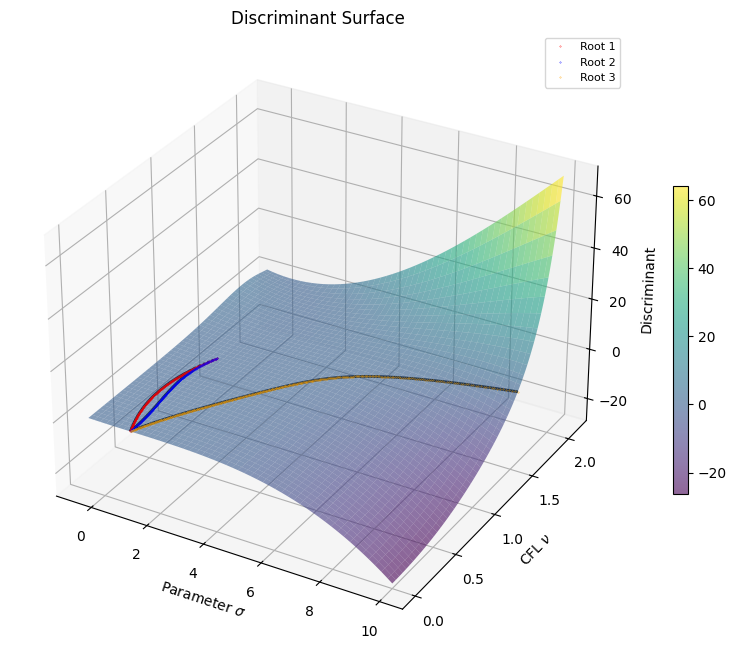

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={
                        'projection': '3d'})  # type: ignore
ax = typing.cast(mpl_toolkits.mplot3d.axes3d.Axes3D, ax)
sigma_values = np.linspace(-.5, 10, 200)
cfl_values = np.linspace(0, 2.1, 200)
sigma_values, cfl_values = np.meshgrid(sigma_values, cfl_values)
discr_numeric = sp.lambdify((cfl, sigma), discriminant_poly.as_expr(), modules="numpy")
discr_values = discr_numeric(cfl_values, sigma_values)
surf = ax.plot_surface(sigma_values, cfl_values, discr_values ,
                        cmap='viridis', alpha=0.6)

ax.contour3D(sigma_values, cfl_values, discr_values, levels=[.0],
        colors='black', linewidths=2, label="Numerical roots")
import warnings

cfl_line = np.linspace(0, 2.1, 500)
colors = ['red', 'blue', 'orange', 'purple', 'green']

sigma_roots = sp.solve(discriminant_poly.as_expr(), sigma)
print(f"Found {len(sigma_roots)} sigma roots")

# Lambdify each root with complex support
sigma_root_funcs = [
    sp.lambdify(cfl, root, modules="numpy") 
    for root in sigma_roots
]

for i, root_func in enumerate(sigma_root_funcs):
    try:
        # Suppress sqrt warnings - we handle complex results below
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)
            
            # Force complex evaluation to handle negative sqrt/cbrt
            cfl_complex = cfl_line.astype(complex)
            sigma_line = root_func(cfl_complex)
        
        # Ensure it's a numpy array
        sigma_line = np.asarray(sigma_line)
        
        # Keep only values where imaginary part is negligible  
        tol = 1e-8
        is_real = np.abs(sigma_line.imag) < tol
        
        # Extract real part where applicable
        sigma_real = np.where(is_real, sigma_line.real, np.nan)
        
        # Mask values outside plot domain
        in_domain = (sigma_real >= -0.5) & (sigma_real <= 10)
        sigma_real = np.where(in_domain, sigma_real, np.nan)
        
        # Only plot if we have some valid points
        if np.any(~np.isnan(sigma_real)):
            z_line = np.zeros_like(cfl_line)
            
            ax.plot(
                sigma_real,
                cfl_line,
                z_line + 0.05,
                color=colors[i % len(colors)],
                linestyle="",
                marker='.',
                markersize=.5,
                linewidth=.1,
                label=f'Root {i+1}',
                zorder=10
            )
            print(f"Root {i}: plotted {np.sum(~np.isnan(sigma_real))} points")
        else:
            print(f"Root {i}: no real values in domain")
            
    except Exception as e:
        print(f"Root {i} error: {e}")

ax.legend(loc='best', fontsize=8)

# ax.plot(sigma_vals, [0]*len(sigma_vals), numerical_max_cfls,
#         'b--', linewidth=2, label='Numerical max over θ')
ax.set_xlabel(r'Parameter $\sigma$')
ax.set_ylabel(r'CFL $\nu$')
# ax.set_zlim(0, 1.5)
ax.set_zlabel(r'Discriminant')
ax.set_title('Discriminant Surface')

# Colour bar – need figure
fig = ax.figure
fig.colorbar(surf, shrink=0.5)
plt.savefig('discriminant-surface.png')
plt.show()

In [167]:
for i, sigma_root_expr in enumerate(sigma_roots):
    print(f"\n--- Root {i+1}: Check ---")
    
    # Substitute σ(ν)
    H_sub = H.subs(sigma, sigma_root_expr)
    dH_dx_sub = sp.diff(H, x).subs(sigma, sigma_root_expr)
    
    H_sub_roots = sp.roots(H_sub, x)
    for root, multiplicity in H_sub_roots.items():
        if multiplicity > 1:
            print("Found tangency point:")
            display(Math(sp.latex(root)))
    break
    # dH_dx_sub_roots = sp.roots(dH_dx_sub, x)



    # try:
    #     # Compute GCD with respect to x
    #     gcd_poly = sp.gcd(H_sub, dH_dx_sub, x)
        
    #     print(f"GCD = {gcd_poly}")
        
    #     # Check degree in x
    #     if sp.degree(gcd_poly, x) >= 1:
    #         print(f"✓ GCD has degree {sp.degree(gcd_poly, x)} in x")
    #         print("  → Common root exists!")
            
    #         # The GCD itself gives the condition on the common root
    #         print(f"  Common root satisfies: {gcd_poly} = 0")
            
    #         # You can solve for x to see the tangency point x(ν)
    #         try:
    #             x_solutions = sp.solve(gcd_poly, x)
    #             print(f"  x(ν) = {x_solutions}")
    #         except:
    #             print("  (Could not solve for x explicitly)")
    #     else:
    #         print(f"✗ GCD is constant: {gcd_poly}")
    #         print("  → No common root")
            
    # except Exception as e:
    #     print(f"Could not compute GCD: {e}")


--- Root 1: Check ---
Found tangency point:


<IPython.core.display.Math object>

In [168]:
root.subs(cfl, -1).simplify()

-1

In [169]:
sp.factor(sp.simplify(factor_poly.as_expr() - 1))
sp.roots(factor_poly - 1, x)
factor_poly.subs({x: sp.cos(sp.pi/3), sigma: 1.2, cfl: 3})
factor_poly.subs({sigma: 3, cfl: 1})
# sp.roots(factor_poly.subs({x: sp.cos(sp.pi/3), sigma: 1.2}))
# sp.roots(factor_poly_prime, x)
# sp.factor(factor_poly_prime.as_expr())
# sp.resultant(factor_poly.as_expr() - 1, factor_poly_prime.as_expr(), x)

x**4/9 + 2*x**3/9 - 2*x**2/3 + 2*x/9 + 10/9

In [170]:
def factor_stability_conditions(expr: sp.Poly, cfl: sp.Symbol) -> list[sp.Expr]:
    """
    Analyzes a stability condition (where expr <= 0 is required for stability)
    and breaks it down into separate inequalities based on its factors.
    """
    coeff, factors = sp.factor_list(expr)  # type: ignore
    factors: list[tuple[sp.Poly, int]]

    inequalities = []

    for factor, power in factors:
        if not factor.has(cfl):
            continue

        # Find roots of this specific factor
        # Checks for UnsolvableFactorError exception can be used to break here
        roots: list[sp.Expr] = sp.roots(factor, cfl, multiple=True, strict=True)
        has_positive_real_root = False

        for root in roots:
            # Ignore purely imaginary/complex roots
            if root.has(sp.I) or root.is_real is False:
                continue

            # 2. Nothing for non-positive real roots
            # We filter out explicitly negative branches (e.g., -sqrt(sigma))
            # A bit of workaround for radicals
            coeff_mul, _ = root.as_coeff_Mul()
            if root.is_nonpositive or coeff_mul < 0:
                continue

            # 1. Inequalities for real positive real roots
            # Assuming standard stability requirement defines an upper bound:
            inequalities.append(cfl <= root)
            has_positive_real_root = True

        # FIXME -- this part need to be circled onto a bit on later
        # 3. Inequalities for irreducible polynomial/quadratic factors
        # If no positive real roots were found, but it's a polynomial in cfl
        # (degree >= 2), we represent the irreducible factor itself.
        if not has_positive_real_root and sp.degree(factor, cfl) >= 2:
            ...
            # inequalities.append(factor <= 0)

    # If no restricting conditions were found (or no factors containing cfl)
    return inequalities

In [171]:
def derive_stability_bound(conditions: list[sp.Expr]) -> sp.LessThan:
    rhss: typing.Iterable[sp.Expr] = map(lambda condition: condition.rhs, filter(
        lambda condition: isinstance(condition, sp.LessThan)
        and condition.lhs == cfl
        and not condition.rhs.has(cfl),
        conditions
    ))
    # display(sp.Min(*rhss))
    return sp.LessThan(cfl, sp.Min(*rhss))

In [172]:
left, interior, right = derive_stability_conditions(
    factor_mod2, wavenumber, cfl)

for location_name, conditions in zip(
    (r"Left endpoint $\theta = 0$:",
     r"Interior points $\theta \in (0, \pi)$:",
     r"Left endpoint $\theta = \pi$:"),
        (left, interior, right), strict=True):
    condition_factors = factor_stability_conditions(conditions, cfl)
    # display(condition_factors)
    bound = derive_stability_bound(condition_factors)

    # DEBUG
#     joiner = r', \\  &'
#     system_latex = rf"""
# $$
# \begin{{aligned}} &
# {joiner.join(map(sp.latex, condition_factors))}
# .\end{{aligned}}
# $$

# """
    conditions_latex = sp.latex(
        conditions.as_expr().simplify().factor(),
        symbol_names=symbol_names | {cfl: r'\nu_{max}'})
    display(Markdown(
            location_name +
            (f"$${conditions_latex} = 0,$$\n" f"$${sp.latex(bound)}$$"
             if condition_factors else " **Unconditionally stable**.")
            ))


with open('left-boundary-stability-condition-polynomial.tex', mode='w') as file:
    file.write(sp.latex(left.as_expr().simplify().factor()))

with open('right-boundary-stability-condition-polynomial.tex', mode='w') as file:
    file.write(sp.latex(right.as_expr().simplify().factor()))

display(Math(sp.latex(right.as_expr().simplify().factor())))

Left endpoint $\theta = 0$: **Unconditionally stable**.

Interior points $\theta \in (0, \pi)$: **Unconditionally stable**.

Left endpoint $\theta = \pi$:$$\frac{4 \left(\nu_{max}^{4} - 4 \nu_{max}^{2} + \sigma - 1\right) \left(\nu_{max}^{4} - 4 \nu_{max}^{2} + \sigma + 2\right)}{9} = 0,$$
$$\nu \leq \min\left(\sqrt{2 - \sqrt{2 - \sigma}}, \sqrt{2 - \sqrt{5 - \sigma}}, \sqrt{\sqrt{2 - \sigma} + 2}, \sqrt{\sqrt{5 - \sigma} + 2}\right)$$

<IPython.core.display.Math object>

In [173]:
def evaluate_nu_max(cfl_expressions: list[sp.Expr], sigma_sym: sp.Symbol, sigma_val: float) -> float:
    """
    Substitutes a numerical sigma value into the purely symbolic cfl expressions
    to find the critical real limit for plotting.
    """
    positive_real_roots = []
    
    for expr in cfl_expressions:
        # Substitute sigma into the exact symbolic root
        val = expr.subs(sigma_sym, sigma_val)
        
        # Evaluate to a complex number to check imaginary parts
        val_num = complex(sp.N(val))
        
        # Filter for real, positive roots
        if abs(val_num.imag) < 1e-12 and val_num.real > 1e-12:
            positive_real_roots.append(val_num.real)
            
    if not positive_real_roots:
        return float('inf')
        
    return min(positive_real_roots)

In [174]:
def solve_cfl_symbolically(conditions: typing.Iterable[sp.Poly], cfl: sp.Symbol) -> list[sp.Expr]:
    """
    Extracts final expressions for the value of cfl.
    Performs strictly symbolic finding of roots (cfl as a function of sigma, etc).
    """
    cfl_expressions = []
    
    for eq in conditions:
        if eq == 0:
            continue
            
        # Symbolically solve for CFL. 
        # (Since the equations only have even powers, this is effectively solving for mu)
        roots = sp.solve(eq, cfl)
        
        # Collect all branches
        cfl_expressions.extend(roots)
        
    return cfl_expressions
conditions = derive_stability_conditions(factor_mod2, wavenumber, cfl)
cfl_exprs = solve_cfl_symbolically(conditions, cfl)


evaluate_nu_max(cfl_exprs, sigma, 0.5)

0.8804857344718374

In [184]:
def print_math(prefix, expr):
    display(Math(prefix + sp.latex(expr)))

# 3. Добавляем оператор гипервязкости 4-го порядка
# -mu4 * (u_{i-2} - 4u_{i-1} + 6u_i - 4u_{i+1} + u_{i+2})

mu4 = sp.Symbol(r'\tilde{\mu}_4', real=True)
hypervisc_term = -mu4 * (u_im2 - 4*u_im1 + 6*u_i - 4*u_ip1 + u_ip2)


coeffs_base = {node: sp.simplify(u_corrected_cfl.coeff(node)) for node in stencil}
modified_scheme = sp.simplify(u_corrected_cfl + hypervisc_term)

coeffs_mod = {node: sp.simplify(modified_scheme.coeff(node)) for node in stencil}

# =====================================================================
# 4. АНАЛИЗ ГРАНИЦ ДЛЯ МЮ_4 (Положительность коэффициентов)
# =====================================================================

# Чтобы коэффициенты при u_{i-1} и u_{i+1} были >= 0:
# C_{i-1} + 4*\mu4 >= 0 => \mu4 >= - C_{i-1} / 4
mu_min_left  = sp.simplify(-coeffs_base[u_im1] / 4)
mu_min_right = sp.simplify(-coeffs_base[u_ip1] / 4)
mu_min_expr = sp.Max(0, mu_min_left, mu_min_right)

# Чтобы коэффициенты при u_{i-2}, u_i, и u_{i+2} оставались >= 0:
# C_{i-2} - \mu4 >= 0 => \mu4 <= C_{i-2}
# C_i     - 6*\mu4 >= 0 => \mu4 <= C_i / 6
# C_{i+2} - \mu4 >= 0 => \mu4 <= C_{i+2}
mu_max_outer_left  = sp.simplify(coeffs_base[u_im2])
mu_max_center      = sp.simplify(coeffs_base[u_i] / 6)
mu_max_outer_right = sp.simplify(coeffs_base[u_ip2])

mu_max_expr = sp.Min(mu_max_outer_left, mu_max_center, mu_max_outer_right)

# Вывод
display(Math(r"\textbf{Ограничения на гипервязкость } \tilde{\mu}_4 = \mu_4 \frac{\Delta t}{\Delta x^4}:"))

print_math(r"\text{Для узлов } i\pm 1 \implies \tilde{\mu}_{4, \min} = \max\left(0, " 
           r"-\frac{C_{i-1}}{4}, -\frac{C_{i+1}}{4}\right) =", mu_min_expr)

print_math(r"\text{Для узлов } i\pm 2 \text{ и } i \implies \tilde{\mu}_{4, \max} = \min\left(C_{i-2}, "
           r"\frac{C_i}{6}, C_{i+2}\right) =", mu_max_expr)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

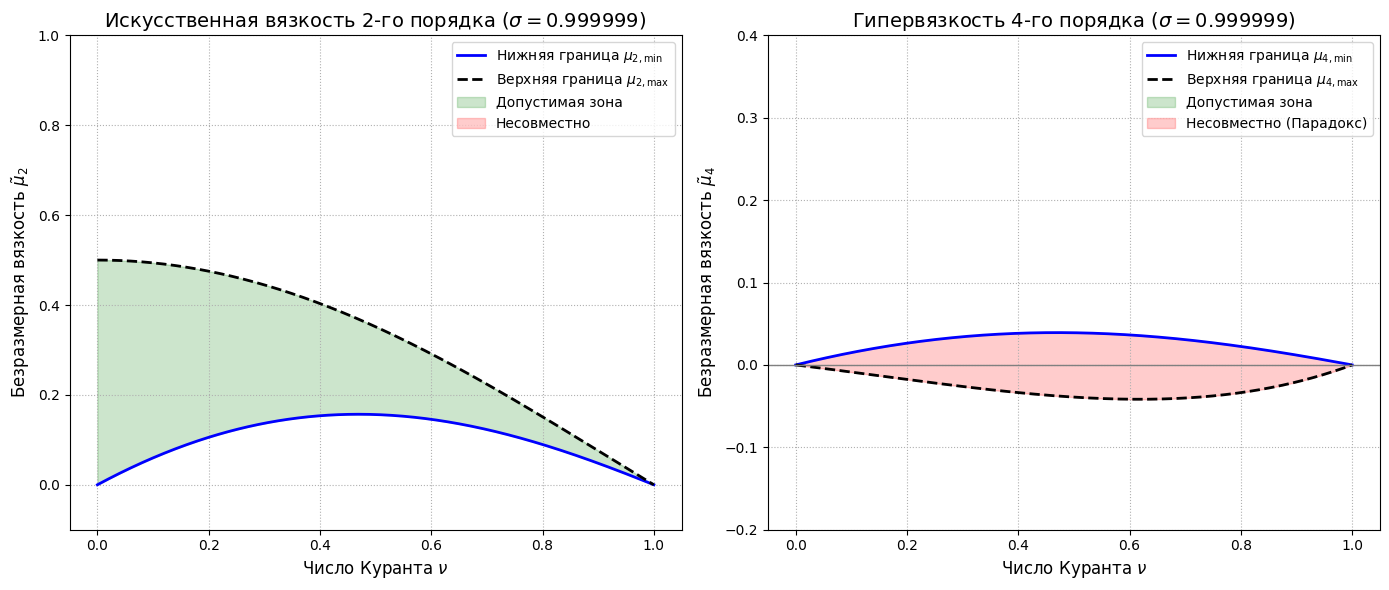

In [191]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Символьное задание коэффициентов
# ==========================================
nu, sigma = sp.symbols('nu sigma')

# Коэффициенты базовой схемы
c_im2 = (-1 + sigma + nu**4 - nu**2 - 2*nu + 2*nu**3) / 24
c_im1 = -(-1 + sigma + nu**3 + nu**4 - 4*nu - 4*nu**2) / 6
c_i   = (3 + sigma + nu**4 - 5*nu**2) / 4
c_ip1 = -(-1 + sigma + nu**4 - nu**3 - 4*nu**2 + 4*nu) / 6
c_ip2 = (-1 + sigma + nu**4 - nu**2 - 2*nu**3 + 2*nu) / 24

# Преобразуем sympy-выражения в быстрые numpy-функции
f_c_im2 = sp.lambdify((nu, sigma), c_im2, 'numpy')
f_c_im1 = sp.lambdify((nu, sigma), c_im1, 'numpy')
f_c_i   = sp.lambdify((nu, sigma), c_i, 'numpy')
f_c_ip1 = sp.lambdify((nu, sigma), c_ip1, 'numpy')
f_c_ip2 = sp.lambdify((nu, sigma), c_ip2, 'numpy')

# ==========================================
# 2. Вычисление данных для графиков
# ==========================================
# Задаем сетку для числа Куранта от 0 до 1
nu_vals = np.linspace(0.0, 1.0, 500)

# Фиксируем свободный параметр (можете поменять, чтобы увидеть, как меняются графики)
sigma_val = 0.999999

# Вычисляем значения коэффициентов на сетке
v_im2 = f_c_im2(nu_vals, sigma_val)
v_im1 = f_c_im1(nu_vals, sigma_val)
v_i   = f_c_i(nu_vals, sigma_val)
v_ip1 = f_c_ip1(nu_vals, sigma_val)
v_ip2 = f_c_ip2(nu_vals, sigma_val)

# Границы для 2-го порядка (классическая вязкость)
mu2_min = np.maximum(0, np.maximum(-v_im1, -v_ip1))
mu2_max = v_i / 2.0

# Границы для 4-го порядка (гипервязкость)
mu4_min = np.maximum(0, np.maximum(-v_im1 / 4.0, -v_ip1 / 4.0))
mu4_max = np.minimum(v_im2, np.minimum(v_i / 6.0, v_ip2))

# ==========================================
# 3. Отрисовка графиков
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ---- График 1: Вязкость 2-го порядка ----
ax1.plot(nu_vals, mu2_min, 'b-', linewidth=2, label=r'Нижняя граница $\mu_{2,\min}$')
ax1.plot(nu_vals, mu2_max, 'k--', linewidth=2, label=r'Верхняя граница $\mu_{2,\max}$')

# Закрашиваем допустимую область (где min <= max)
valid_2 = mu2_min <= mu2_max
ax1.fill_between(nu_vals, mu2_min, mu2_max, where=valid_2, color='green', alpha=0.2, label='Допустимая зона')
ax1.fill_between(nu_vals, mu2_max, mu2_min, where=~valid_2, color='red', alpha=0.2, label='Несовместно')

ax1.set_title(f'Искусственная вязкость 2-го порядка ($\sigma={sigma_val}$)', fontsize=14)
ax1.set_xlabel(r'Число Куранта $\nu$', fontsize=12)
ax1.set_ylabel(r'Безразмерная вязкость $\tilde{\mu}_2$', fontsize=12)
ax1.set_ylim([-0.1, 1.0])
ax1.grid(True, linestyle=':')
ax1.legend()

# ---- График 2: Гипервязкость 4-го порядка ----
ax2.plot(nu_vals, mu4_min, 'b-', linewidth=2, label=r'Нижняя граница $\mu_{4,\min}$')
ax2.plot(nu_vals, mu4_max, 'k--', linewidth=2, label=r'Верхняя граница $\mu_{4,\max}$')

# Закрашиваем допустимую область
valid_4 = mu4_min <= mu4_max
ax2.fill_between(nu_vals, mu4_min, mu4_max, where=valid_4, color='green', alpha=0.2, label='Допустимая зона')
ax2.fill_between(nu_vals, mu4_max, mu4_min, where=~valid_4, color='red', alpha=0.2, label='Несовместно (Парадокс)')

ax2.set_title(f'Гипервязкость 4-го порядка ($\sigma={sigma_val}$)', fontsize=14)
ax2.set_xlabel(r'Число Куранта $\nu$', fontsize=12)
ax2.set_ylabel(r'Безразмерная вязкость $\tilde{\mu}_4$', fontsize=12)
ax2.set_ylim([-0.2, 0.4])
ax2.axhline(0, color='gray', linewidth=1) # Линия нуля
ax2.grid(True, linestyle=':')
ax2.legend()

plt.tight_layout()
plt.show()

### Numerical results

In [175]:
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt
import matplotlib.axes
import mpl_toolkits.mplot3d.axes3d
import matplotlib.colors
import matplotlib.figure

In [176]:
theta_range = (0.0, 2 * np.pi)
cfl_range = (0.01, 1.5)
sigma_range = (0, 1.2)

In [177]:
factor_numeric: typing.Callable[
    [npt.ArrayLike, npt.ArrayLike, float],
    npt.NDArray[np.floating]
] = sp.lambdify((wavenumber, cfl, sigma), factor, modules='numpy')

In [178]:
def compute_max_stable_cfl(sigma: float,
                           theta_range: tuple[float, float],
                           cfl_range: tuple[float, float],
                           n_theta: int = 500,
                           n_cfl_test: int = 600,
                           tol: float = 1e-10) -> float:
    """
    Find the largest CFL such that |G|^2 <= 1 + tol for all theta
    (global stability bound for a given sigma).

    Scans from cfl_range[1] downwards. Returns 0 if no stable value found.
    """
    fine_theta = np.linspace(*theta_range, n_theta)
    for cfl_test in np.linspace(cfl_range[1], cfl_range[0], n_cfl_test):
        factor_values = factor_numeric(fine_theta, cfl_test, sigma)
        if np.all(np.abs(factor_values)**2 <= 1.0 + tol):
            return cfl_test
    return 0.0


def plot_stability_region(theta: np.ndarray,
                          cfl: np.ndarray,
                          factor_mod_sq: np.ndarray,
                          sigma: float,
                          ax: plt.Axes | None = None,
                          colorbar: bool = True):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    # 1. HARD-CAP THE VISUAL RANGE
    # We focus entirely on the boundary. If max is huge, cap it at 2.0.
    val_min = min(factor_mod_sq.min(), 0.95)
    val_max = 2.5  # Force the top of the color scale to be close to 1.0
    
    # Fallback in case the entire array happens to be entirely < 2.0
    if factor_mod_sq.max() < val_max:
        val_max = max(factor_mod_sq.max(), 1.05)

    norm = matplotlib.colors.TwoSlopeNorm(vcenter=1.0, vmin=val_min, vmax=val_max)

    # 2. DENSE LEVELS AROUND 1.0
    # Because we cap at val_max, these 50 levels are tightly packed near the critical boundary.
    levels = np.linspace(val_min, val_max, 50)

    # extend='both' is the magic keyword here: 
    # Any value > 2.0 gets lumped into the maximum color (Solid Red)
    contour = ax.contourf(theta, cfl, factor_mod_sq,
                          levels=levels,
                          cmap='RdYlGn_r',
                          norm=norm,
                          extend='both', 
                          alpha=0.85)

    ax.contour(theta, cfl, factor_mod_sq, levels=[1.0],
               colors='black', linewidths=2.5)

    ax.set_xlabel(r'Wavenumber $\theta = k\,\Delta x$')
    ax.set_ylabel(r'CFL-number $\nu$')
    ax.set_title(rf'$\sigma = {sigma}$,  $|G|^2$')

    theta_range = (theta.min(), theta.max())
    cfl_range = (cfl.min(), cfl.max())

    numerical_max_cfl = compute_max_stable_cfl(
        sigma, theta_range, cfl_range)
    if numerical_max_cfl > 0:
        ax.hlines(numerical_max_cfl, *theta_range,
                  colors='black', linestyles='--', linewidth=2.5,
                  label=fr'$\nu \approx {numerical_max_cfl:.4f}$')
        ax.legend(loc='lower right')
        
    if colorbar:
        # We explicitly label the colorbar to let the user know the red extends to infinity
        cbar = ax.figure.colorbar(contour, ax=ax, label=r'$|G|^2$')
        
        # Optional styling: If max value in data is over our cap, rename the top tick
        if factor_mod_sq.max() > val_max:
            ticks = cbar.get_ticks()
            cbar.set_ticks(ticks)  # Explicitly lock the locator to match our custom labels length
            
            tick_labels = [f"{t:.2f}" for t in ticks]
            tick_labels[-1] = f"> {val_max:.1f}"
            cbar.set_ticklabels(tick_labels)

    return ax

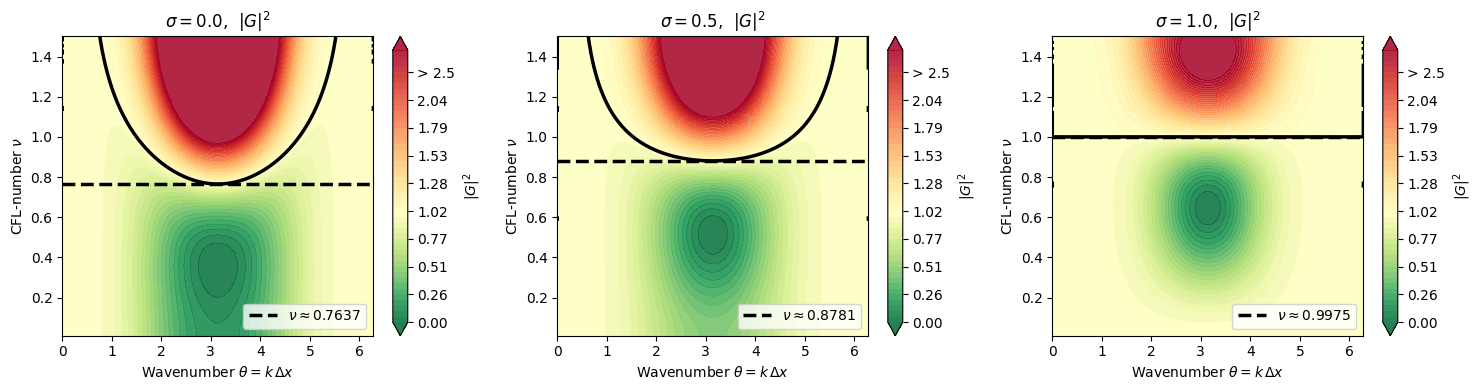

In [179]:
def compute_factor_mod_sq_grid(
        theta_range: tuple[float, float] = theta_range,
        cfl_range: tuple[float, float] = cfl_range,
        sigma: float = 0.0, n_theta: int = 200, n_cfl: int = 100):
    """Numerically compute |G|^2 on a (theta, cfl) grid for a given sigma."""
    theta_vals = np.linspace(*theta_range, n_theta)
    cfl_vals = np.linspace(*cfl_range,   n_cfl)
    theta, CFL = np.meshgrid(theta_vals, cfl_vals)
    factor = factor_numeric(theta, CFL, sigma)
    factor_mod_sq = np.abs(factor)**2
    return theta, CFL, factor_mod_sq


def plot_stability_region_multi(
        sigma_values: typing.Sequence[float],
        theta_range: tuple[float, float] = theta_range,
        cfl_range: tuple[float, float] = cfl_range,
        n_theta=200, n_cfl=100):
    fig, axes = plt.subplots(1, len(sigma_values),
                             figsize=(5 * len(sigma_values), 4),
                             squeeze=False)
    axes: typing.Iterable[matplotlib.axes.Axes] = axes[0]

    for ax, sigma in zip(axes, sigma_values):
        theta, cfl, factor_mod2 = compute_factor_mod_sq_grid(
            theta_range, cfl_range, sigma, n_theta, n_cfl)
        plot_stability_region(theta, cfl, factor_mod2,
                              sigma, ax=ax, colorbar=True)

    fig.tight_layout()


plot_stability_region_multi(sigma_values=(0.0, 0.5, 1.0))
plt.savefig('amplification-factor-parameter-profile.png')
plt.show()

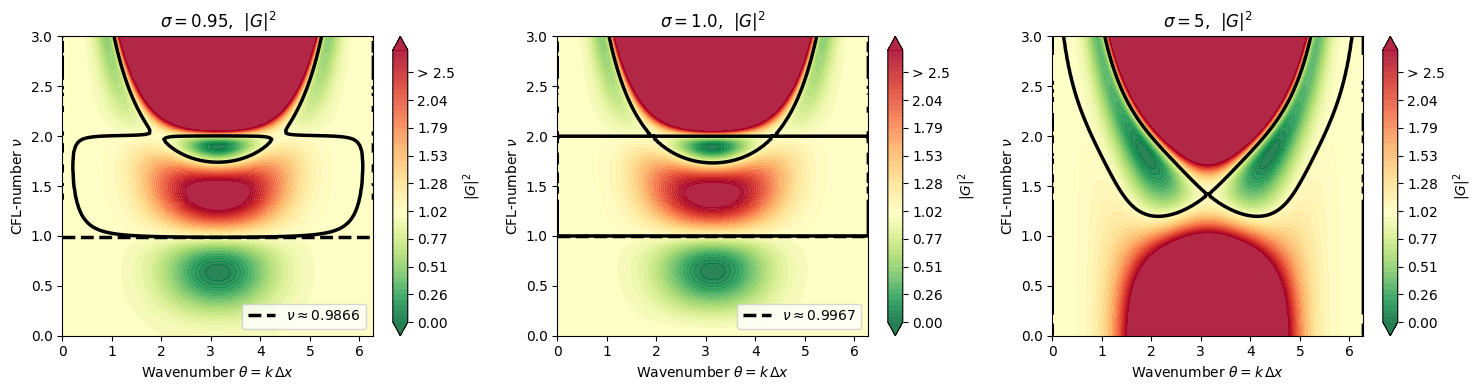

In [180]:
plot_stability_region_multi(cfl_range=(0, 3), sigma_values=(0.95, 1.00, 5))
plt.savefig('extremal-paramter-amplification-factor-parameter-profile.png')
# plot_stability_region_multi(sigma_values=(1.2,))

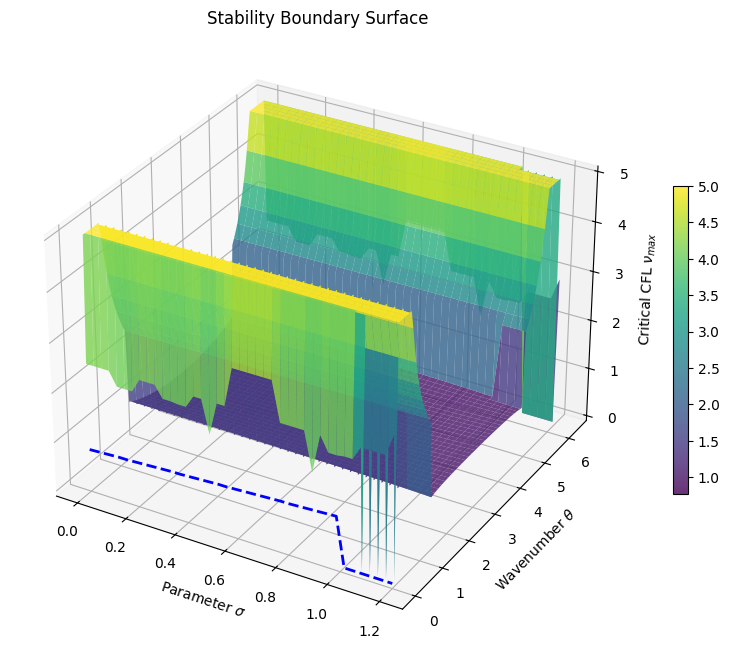

In [181]:
def compute_stability_surface(sigma_vals: np.ndarray,
                              theta_vals: np.ndarray,
                              cfl_range: tuple[float, float] = cfl_range,
                              n_iter: int = 50):
    """Binary search for critical CFL at each (sigma, theta)."""
    sigma, theta = np.meshgrid(sigma_vals, theta_vals)
    cfl_bound = np.zeros_like(sigma)

    for i, sig in enumerate(sigma_vals):
        for j, th in enumerate(theta_vals):
            cfl_low, cfl_high = cfl_range
            for _ in range(n_iter):
                cfl_mid = (cfl_low + cfl_high) / 2
                factor_val = factor_numeric(th, cfl_mid, sig)
                if np.abs(factor_val)**2 > 1.0:
                    cfl_high = cfl_mid
                else:
                    cfl_low = cfl_mid
            cfl_bound[j, i] = cfl_mid
    return sigma, theta, cfl_bound


def plot_stability_surface(
        sigma: np.ndarray, theta: np.ndarray, cfl_bound: np.ndarray,
        ax: mpl_toolkits.mplot3d.axes3d.Axes3D | None = None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={
                               'projection': '3d'})  # type: ignore
        ax = typing.cast(mpl_toolkits.mplot3d.axes3d.Axes3D, ax)

    surf = ax.plot_surface(sigma, theta, cfl_bound,
                           cmap='viridis', alpha=0.8)

    sigma_vals = sigma[0, :]  # unique sigma values
    theta_range = (theta.min(), theta.max())
    cfl_range = (cfl_bound.min(), cfl_bound.max())

    numerical_max_cfls = np.array(
        [compute_max_stable_cfl(sig, theta_range, cfl_range)
         for sig in sigma_vals])
    ax.plot(sigma_vals, [0]*len(sigma_vals), numerical_max_cfls,
            'b--', linewidth=2, label='Numerical max over θ')
    ax.set_xlabel(r'Parameter $\sigma$')
    ax.set_ylabel(r'Wavenumber $\theta$')
    ax.set_zlabel(r'Critical CFL $\nu_{max}$')
    ax.set_title('Stability Boundary Surface')

    # Colour bar – need figure
    fig = ax.figure
    fig.colorbar(surf, shrink=0.5)

    return ax


def plot_stability_surface_figure(
        sigma_range: tuple[float, float] = sigma_range,
        theta_range: tuple[float, float] = theta_range,
        cfl_range: tuple[float, float] = cfl_range,
        n_sigma=40, n_theta=100, n_cfl=80):
    """Convenience: create 3D figure, compute and plot surface."""
    sigma = np.linspace(*sigma_range, n_sigma)
    theta = np.linspace(*theta_range, n_theta)
    sigma, theta, cfl_bound = compute_stability_surface(
        sigma, theta, cfl_range)
    plot_stability_surface(sigma, theta, cfl_bound)


plot_stability_surface_figure(cfl_range=(0,5))
plt.savefig('cfl-stability-boundary-surface.png')
plt.show()

<lambdifygenerated-68>:2: RuntimeWarning: invalid value encountered in sqrt
  return sqrt(2 - sqrt(5 - sigma))


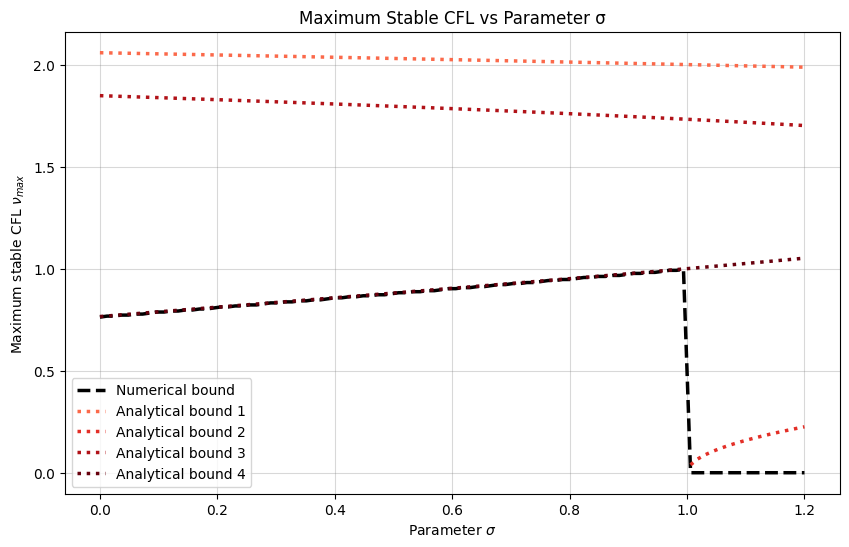

In [182]:
def compute_max_cfl_vs_sigma(sigma_vals: np.ndarray,
                             theta_range: tuple[float, float] = theta_range,
                             cfl_range: tuple[float, float] = cfl_range,
                             n_theta=500, n_cfl_test=300,
                             tol=1e-12):
    """Scan from high to low CFL to find max stable value for each sigma."""
    fine_theta = np.linspace(*theta_range, n_theta)
    max_cfl_vals = []
    for sig in sigma_vals:
        cfl_max = None
        for cfl_test in np.linspace(cfl_range[1], cfl_range[0], n_cfl_test):
            factor_values = factor_numeric(fine_theta, cfl_test, sig)
            if np.all(np.abs(factor_values)**2 <= 1.0 + tol):
                cfl_max = cfl_test
                break
        max_cfl_vals.append(cfl_max or 0)
    return sigma_vals, np.array(max_cfl_vals)


def plot_max_cfl_vs_sigma(sigma_vals: np.ndarray,
                          max_cfl_vals: np.ndarray,
                          ax: plt.Axes | None = None,
                          label: str = 'Numerical bound',
                          color: str | None = None,
                          analytical_func: typing.Callable | None = None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    # CONSISTENCY: Default to Black Dashed if color isn't strictly provided
    plot_color = color if color else 'black'
    ax.plot(sigma_vals, max_cfl_vals, linewidth=2.5,
            label=label, color=plot_color, linestyle='--')

    # Differentiating analytical lines if there are multiple
    colors = plt.cm.Reds(np.linspace(0.5, 1, 4)) # type: ignore
    
    for idx, expr in enumerate(condition_factors[:4]):
        analytical_func = sp.lambdify((sigma), expr.rhs, modules='numpy')
        analytical_vals = [analytical_func(s) for s in sigma_vals]
        ax.plot(sigma_vals, analytical_vals, 
                color=colors[idx], linestyle=':', linewidth=2.5,
                label=f'Analytical bound {idx+1}')

    ax.set_xlabel(r'Parameter $\sigma$')
    ax.set_ylabel(r'Maximum stable CFL $\nu_{max}$')
    ax.set_title('Maximum Stable CFL vs Parameter σ')
    
    # Improve grid styling
    ax.grid(True, which='major', color='gray', alpha=0.3)
    ax.grid(True, which='minor', color='gray', alpha=0.1)
    ax.legend()
    return ax


def plot_max_cfl_vs_sigma_figure(sigma_range=sigma_range,
                                 theta_range=theta_range,
                                 cfl_range=cfl_range,
                                 n_sigma=100,
                                 analytical_func: typing.Callable | None = None):
    """Convenience: create figure with one axis, compute and plot."""
    sigma_vals = np.linspace(*sigma_range, n_sigma)
    sigma_vals, max_cfl = compute_max_cfl_vs_sigma(sigma_vals, theta_range,
                                                   cfl_range)
    plot_max_cfl_vs_sigma(sigma_vals, max_cfl, analytical_func=analytical_func)

plot_max_cfl_vs_sigma_figure()
plt.savefig('cfl-bound-vs-parameter.png')
plt.show()

For the exact solution: $u(x,t) ∝ \exp(i(kx - ωt))$ with $ω = ak$ (non-dispersive)

Numerical scheme: $G = |G| \exp(-iφ)$ where
- $|G| < 1$ → dissipation (amplitude decay)
- $φ ≠ ν*θ$ → dispersion (phase error)


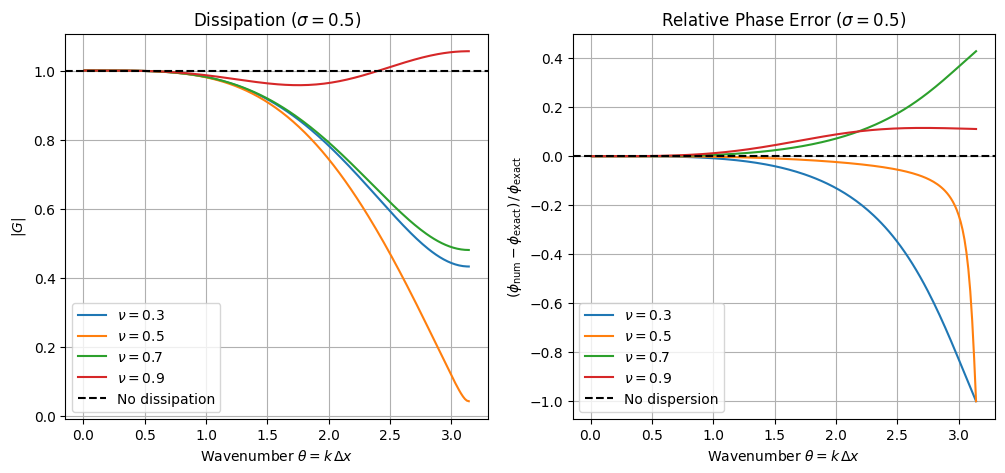

In [183]:
def dissipation_dispersion(
    sigma_value: np.floating,
    cfl_values: npt.NDArray[np.floating],
    n_theta: int,
):
    theta_values = np.linspace(0.01, np.pi, n_theta)
    # For stacked operation
    cfl_values = np.expand_dims(cfl_values, axis=-1)
    factor_values = factor_numeric(theta_values, cfl_values, sigma_value)
    phi_numeric = -np.angle(factor_values)
    phi_exact = cfl_values * theta_values
    phase_errors = (phi_numeric - phi_exact) / (phi_exact + 1e-12)
    return theta_values, np.abs(factor_values), phase_errors


def plot_dissipation(
    sigma_value: np.floating, *,
    cfl_values: npt.NDArray[np.floating],
    theta_values: npt.NDArray[np.floating],
    factor_values: npt.NDArray[np.floating],
    ax: matplotlib.axes.Axes,
):
    for cfl_value, data in zip(cfl_values, factor_values):
        ax.plot(theta_values, data, label=fr'$\nu = {cfl_value}$')

    ax.axhline(1.0, color='k', linestyle='--', label='No dissipation')
    ax.set_xlabel(r'Wavenumber $\theta = k\,\Delta x$')
    ax.set_ylabel(r'$|G|$')
    ax.set_title(rf'Dissipation ($\sigma = {sigma_value}$)')
    ax.legend(loc='lower left')
    ax.grid(True)

    return ax


def plot_dispersion(
    sigma_value: np.floating, *,
    cfl_values: npt.NDArray[np.floating],
    theta_values: npt.NDArray[np.floating],
    phase_errors: npt.NDArray[np.floating],
    ax: matplotlib.axes.Axes,
):
    for cfl_value, data in zip(cfl_values, phase_errors):
        ax.plot(theta_values, data, label=fr'$\nu = {cfl_value}$')

    ax.axhline(0.0, color='k', linestyle='--', label='No dispersion')
    ax.set_xlabel(r'Wavenumber $\theta = k\,\Delta x$')
    ax.set_ylabel(
        r'$(\phi_{\mathrm{num}} - \phi_{\mathrm{exact}})\,/\,\phi_{\mathrm{exact}}$'
    )
    ax.set_title(rf'Relative Phase Error ($\sigma = {sigma_value}$)')
    ax.legend(loc='lower left')
    ax.grid(True)

    return ax


def plot_dissipation_dispersion(
    sigma_value: np.floating = np.float64(0.5),
    cfl_values: npt.ArrayLike = (0.3, 0.5, 0.7, 0.9),  # pyright: ignore
    n_theta: int = 200,
    axes: tuple[matplotlib.axes.Axes, matplotlib.axes.Axes] | None = None,
):
    cfl_values: npt.NDArray[np.floating] = np.array(cfl_values)
    theta_values, factor_values, phase_errors = dissipation_dispersion(
        sigma_value=sigma_value, cfl_values=cfl_values, n_theta=n_theta
    )

    if axes is None:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        # fig.set_layout_engine('tight')

    axes = typing.cast(tuple[matplotlib.axes.Axes, matplotlib.axes.Axes], axes)

    ax_dissipation, ax_dispersion = axes
    plot_dissipation(
        sigma_value=sigma_value, cfl_values=cfl_values,
        theta_values=theta_values, factor_values=factor_values, ax=ax_dissipation)
    plot_dispersion(
        sigma_value=sigma_value, cfl_values=cfl_values,
        theta_values=theta_values, phase_errors=phase_errors, ax=ax_dispersion)

    return axes


plot_dissipation_dispersion()
plt.savefig('dissipation-dispersion-profile.png')
plt.show()